In [1]:
import sys
import os
import glob
import aubio
import numpy as np
from matplotlib import pyplot as plt
from PIL import Image
from scipy import ndimage

print(sys.path)

['/home/gabriel/git/rizhom/env/lib/python36.zip', '/home/gabriel/git/rizhom/env/lib/python3.6', '/home/gabriel/git/rizhom/env/lib/python3.6/lib-dynload', '/usr/lib/python3.6', '', '/home/gabriel/git/rizhom/env/local/lib/python3.6/site-packages', '/home/gabriel/git/rizhom/env/lib/python3.6/site-packages', '/home/gabriel/git/rizhom/env/local/lib/python3.6/site-packages/IPython/extensions', '/home/gabriel/.ipython']


In [2]:
data_path = "../data/"
rec_name="rec_1"
paths = sorted(glob.glob(data_path + rec_name + "/img*.jpg"))
im_mask = np.array(Image.open(data_path + rec_name + "/mask.jpg"))[:,:,1].clip(max=1)
print(im_mask.shape)
data = None
for i, file in enumerate(paths):
    im = np.array(Image.open(file)).astype(np.int16)[:,:,1]
    if data is None:
        data = np.zeros([len(paths) - 1, im.shape[0], im.shape[1]])
        im0 = im
    data[i-1,:,:] = np.sqrt((im.astype("float") - im0.astype("float")) ** 2)*im_mask
    #print(i, np.min(data[i-1]), np.max(data[i-1]))
data.shape

(1080, 1920)


(179, 1080, 1920)

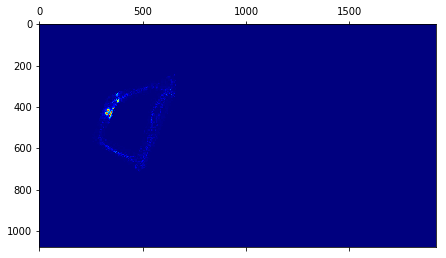

In [77]:
plt.matshow(data[50], cmap='jet')

In [78]:
x_off = (200, 800)
y_off = (200, 700)
pixel_cos = []
pix_imgs = data[::3]
kernel = np.ones((40, 40))
len(pix_imgs)
for idx, img in enumerate(pix_imgs):
    conv = ndimage.convolve(img[x_off[0]:x_off[1],y_off[0]:y_off[1]], kernel, mode='constant')
    pixel_cos.append(np.array(np.unravel_index(np.argmax(conv), conv.shape)) + [x_off[0], y_off[0]])
    print("Pixel Nr:", idx, ". Co:", pixel_cos[-1])

Pixel Nr: 0 . Co: [308 542]
Pixel Nr: 1 . Co: [315 519]
Pixel Nr: 2 . Co: [323 493]
Pixel Nr: 3 . Co: [331 475]
Pixel Nr: 4 . Co: [336 459]
Pixel Nr: 5 . Co: [343 437]
Pixel Nr: 6 . Co: [348 419]
Pixel Nr: 7 . Co: [353 409]
Pixel Nr: 8 . Co: [358 395]
Pixel Nr: 9 . Co: [387 350]
Pixel Nr: 10 . Co: [366 375]
Pixel Nr: 11 . Co: [385 355]
Pixel Nr: 12 . Co: [389 350]
Pixel Nr: 13 . Co: [391 348]
Pixel Nr: 14 . Co: [388 354]
Pixel Nr: 15 . Co: [393 352]
Pixel Nr: 16 . Co: [419 343]
Pixel Nr: 17 . Co: [437 333]
Pixel Nr: 18 . Co: [451 328]
Pixel Nr: 19 . Co: [467 323]
Pixel Nr: 20 . Co: [482 318]
Pixel Nr: 21 . Co: [497 313]
Pixel Nr: 22 . Co: [511 307]
Pixel Nr: 23 . Co: [524 306]
Pixel Nr: 24 . Co: [567 303]
Pixel Nr: 25 . Co: [567 302]
Pixel Nr: 26 . Co: [565 303]
Pixel Nr: 27 . Co: [567 307]
Pixel Nr: 28 . Co: [577 315]
Pixel Nr: 29 . Co: [588 326]
Pixel Nr: 30 . Co: [598 339]
Pixel Nr: 31 . Co: [608 357]
Pixel Nr: 32 . Co: [614 371]
Pixel Nr: 33 . Co: [624 387]
Pixel Nr: 34 . Co: [629 

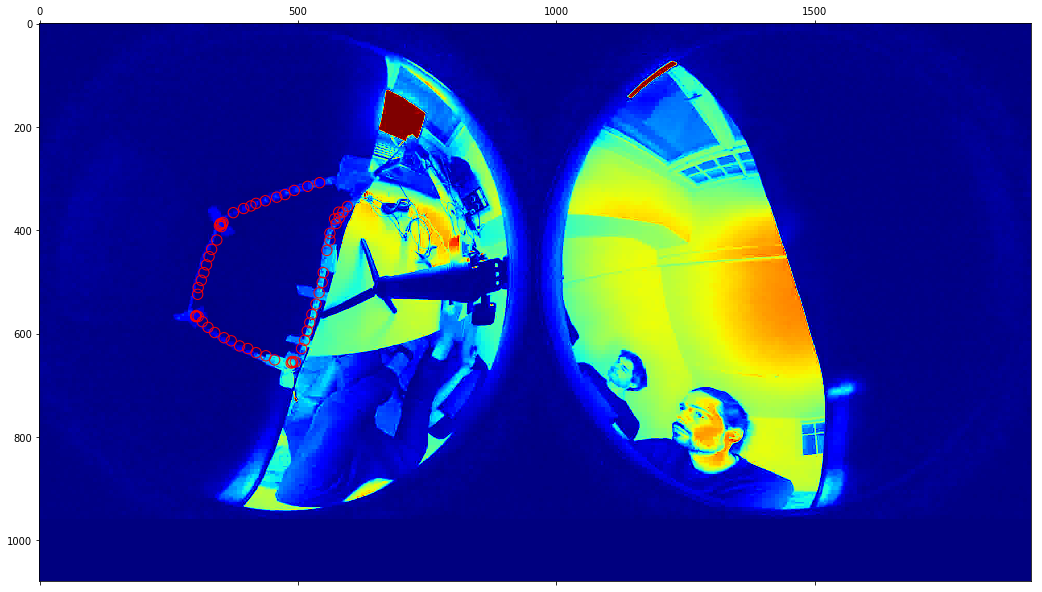

In [89]:
x_off = (200, 800)
y_off = (200, 700)
plt.figure(figsize=(20,10))
plt.matshow(im0, cmap='jet', fignum=1)

ax = plt.gca()
for co in pixel_cos:    
    ax.add_artist(plt.Circle(co[::-1], 10, color='r', fill=False))

In [44]:
def unit_vector(vector):
    """ Returns the unit vector of the vector.  """
    return vector / np.linalg.norm(vector)

def angle_between(v1, v2):
    """ Returns the angle in radians between vectors 'v1' and 'v2'::

            >>> angle_between((1, 0, 0), (0, 1, 0))
            1.5707963267948966
            >>> angle_between((1, 0, 0), (1, 0, 0))
            0.0
            >>> angle_between((1, 0, 0), (-1, 0, 0))
            3.141592653589793
    """
    v1_u = unit_vector(v1)
    v2_u = unit_vector(v2)
    return np.arccos(np.clip(np.dot(v1_u, v2_u), -1.0, 1.0))

In [64]:
polar_cos = []
radius = im0.shape[1]/4
mid_bottom = np.array([radius]*2)
mid_top = np.array([radius, im0.shape[1]/2 + radius])

print("radius:", radius, "mid_bottom:", mid_bottom, "mid_top :", mid_top)
for co in pixel_cos:
    if co[1] > im0.shape[1]/2: # Top Sphere Sphere
        theta = (np.linalg.norm(co - mid_top) / radius) * np.pi / 2 # 0 - 90deg
        phi = angle_between(co - mid_top, np.array([0, -1])) # 0 - 360deg
    else:                      # Bottom Sphere Half
        theta = np.pi - (np.linalg.norm(co - mid_bottom) / radius) * np.pi / 2 # 90 - 180deg
        phi = angle_between(co - mid_bottom, np.array([0, 1])) # 0 - 360deg
    polar_cos.append([theta, phi])
#print(polar_cos)

radius: 480.0 mid_bottom: [480. 480.] mid_top : [ 480. 1440.]


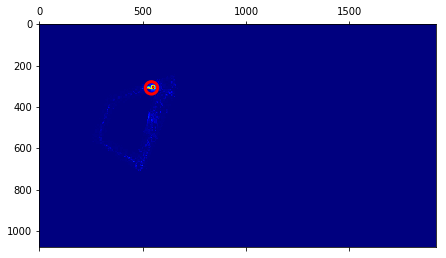

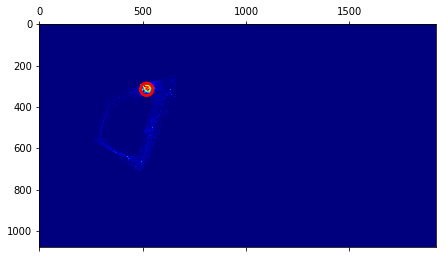

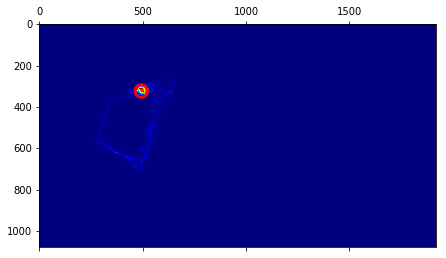

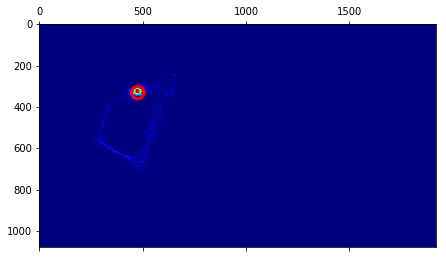

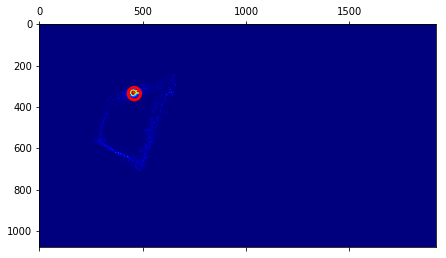

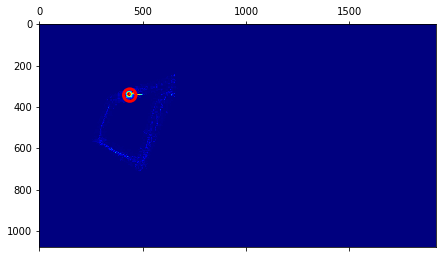

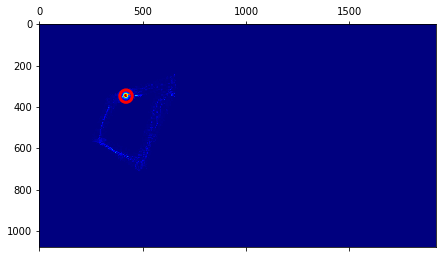

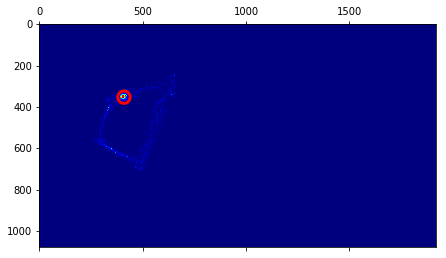

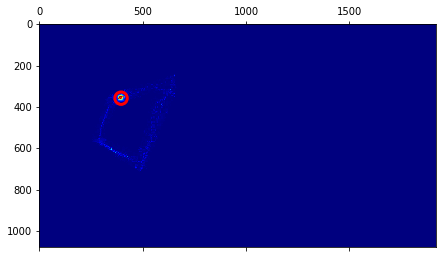

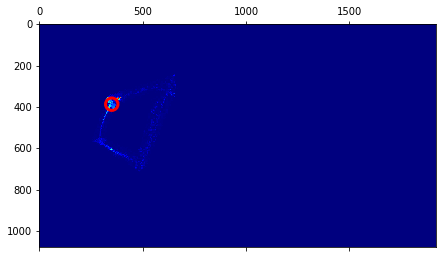

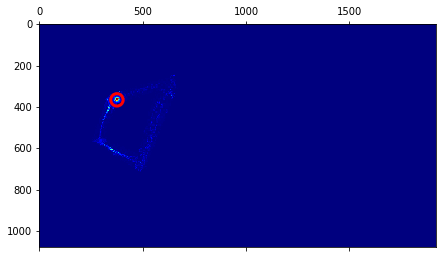

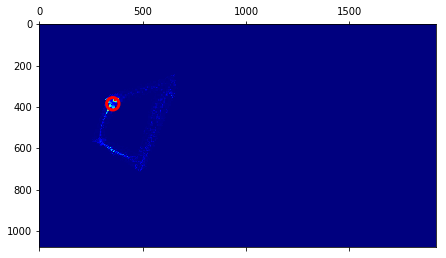

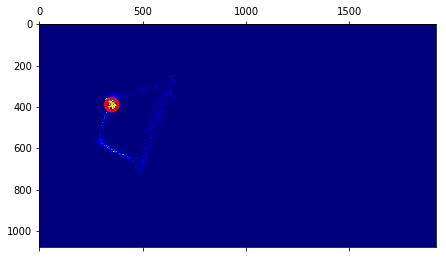

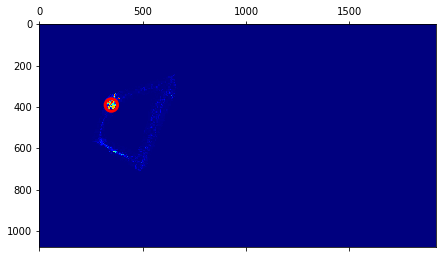

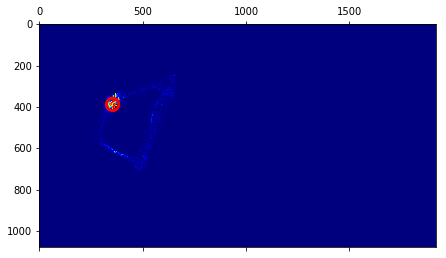

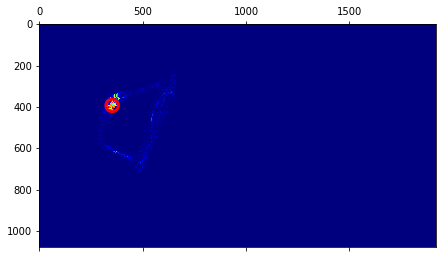

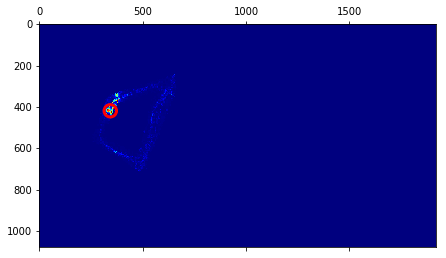

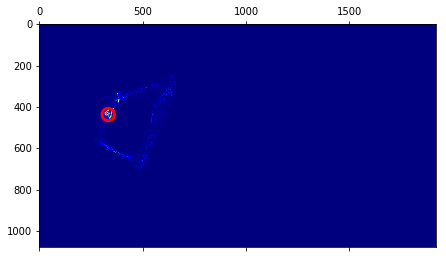

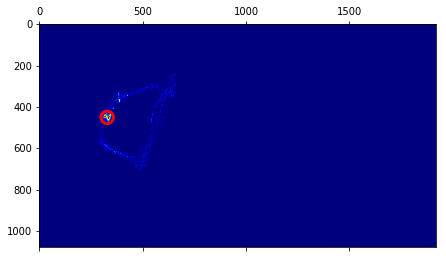

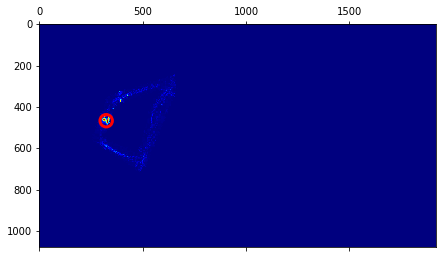

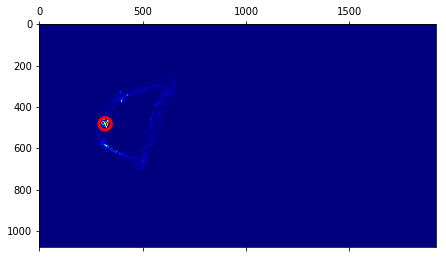

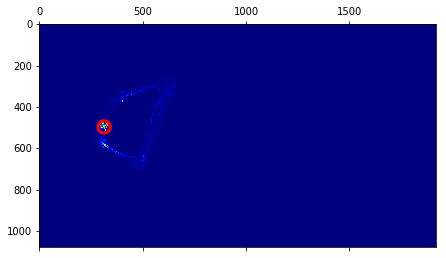

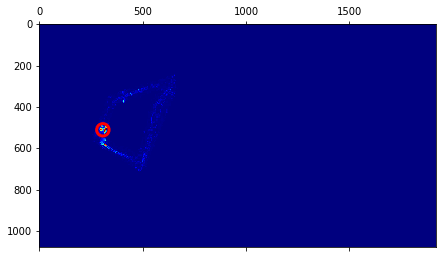

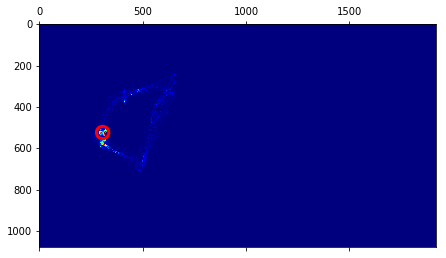

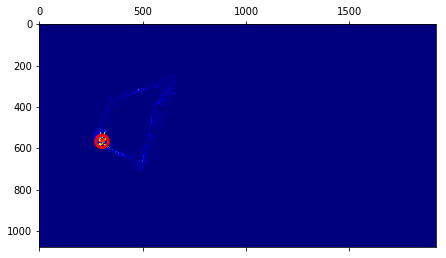

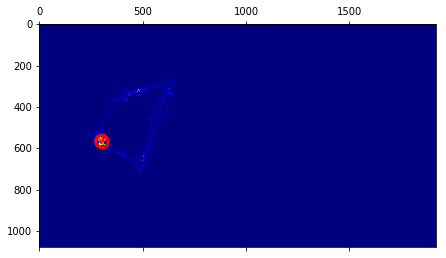

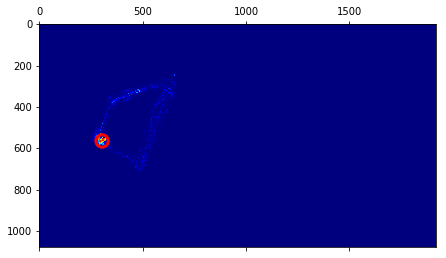

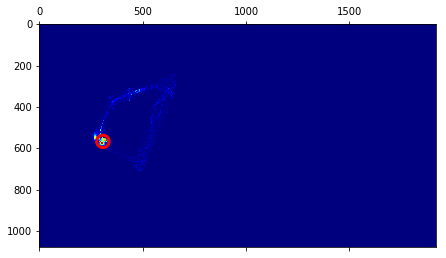

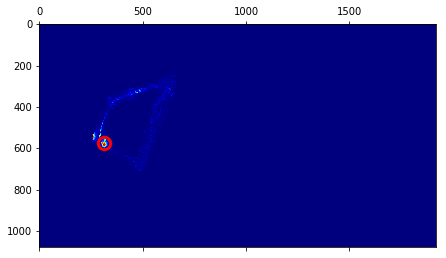

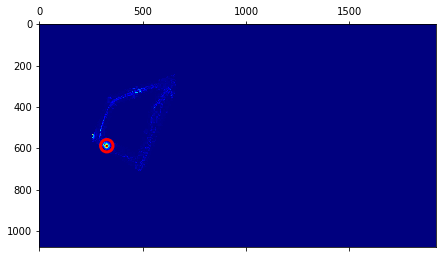

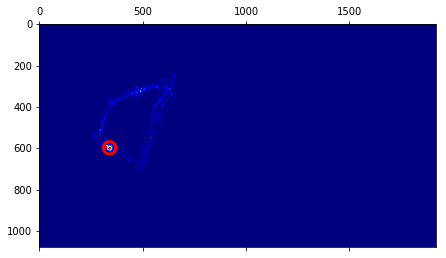

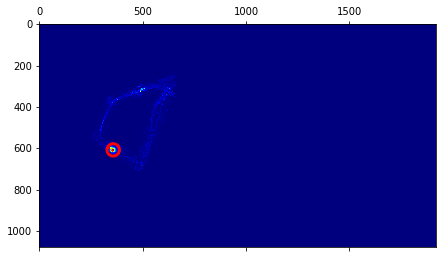

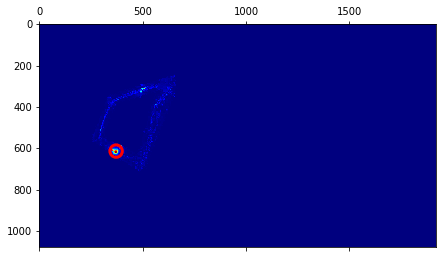

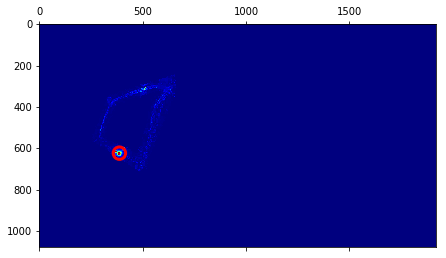

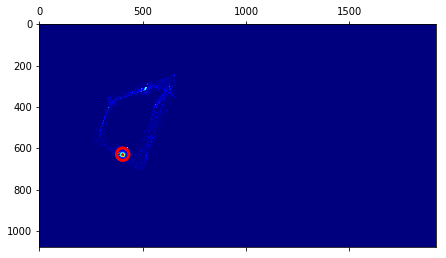

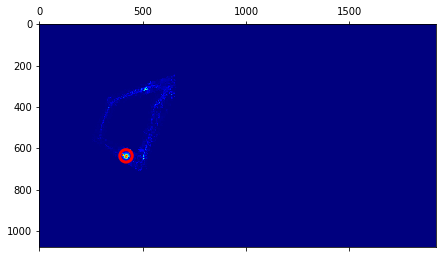

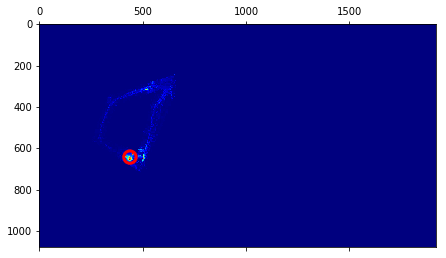

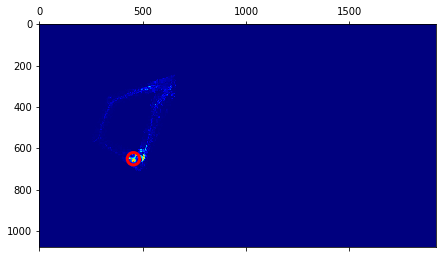

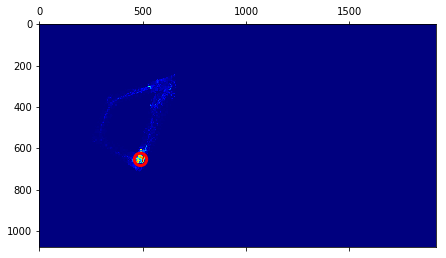

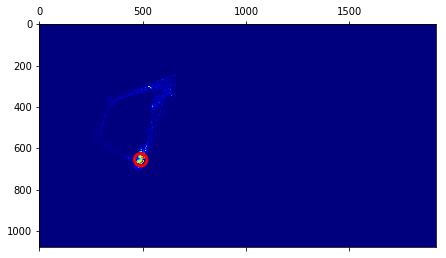

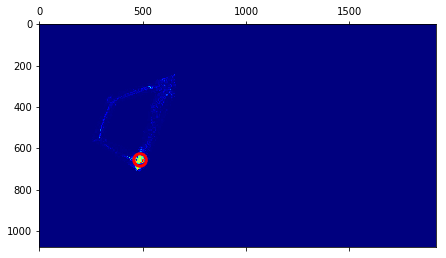

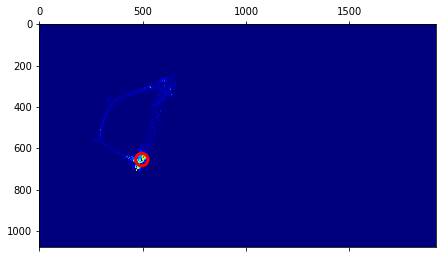

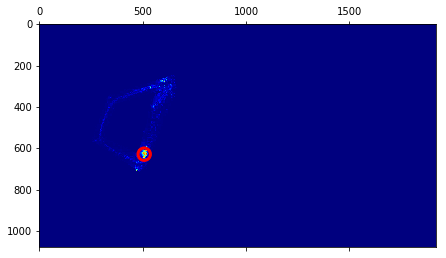

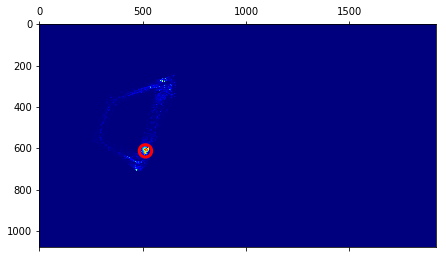

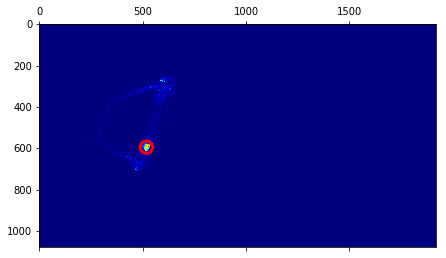

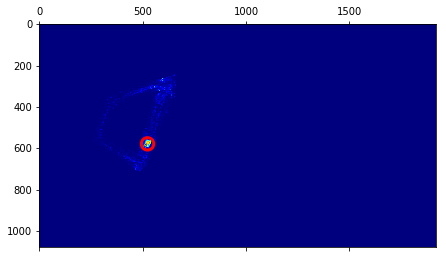

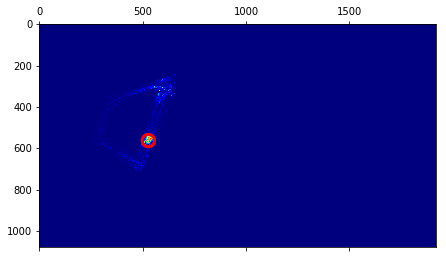

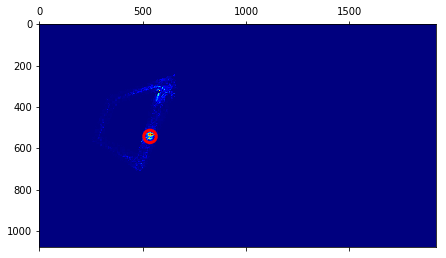

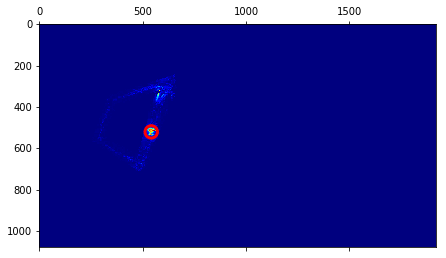

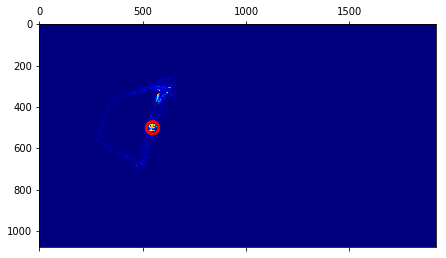

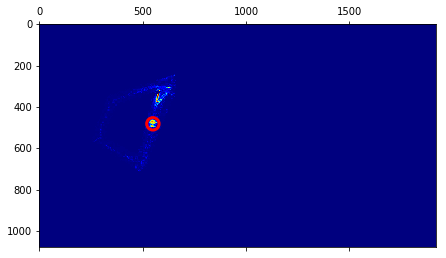

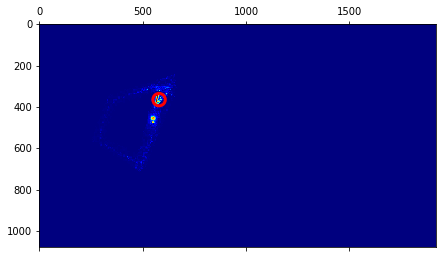

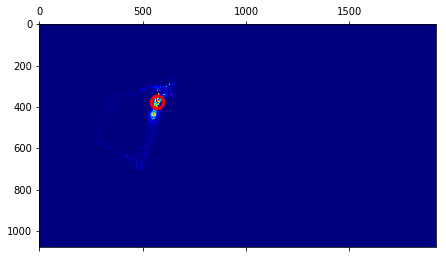

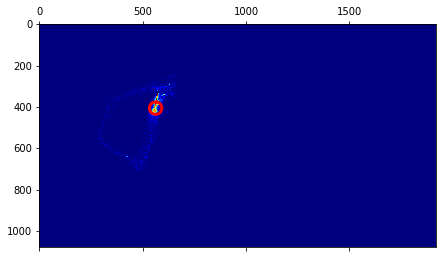

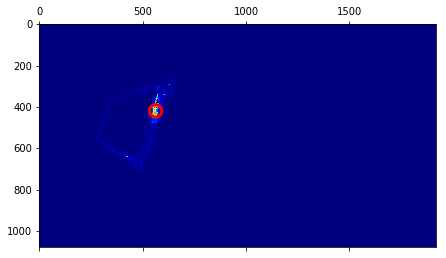

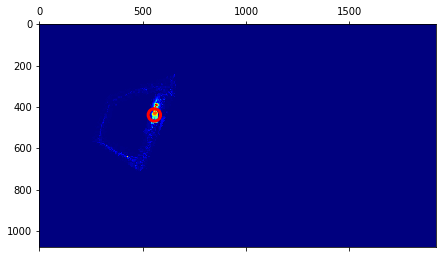

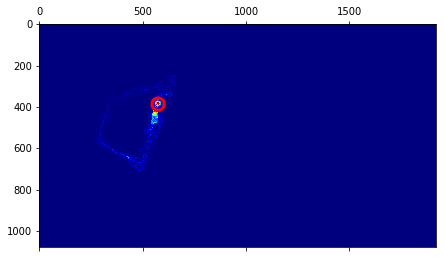

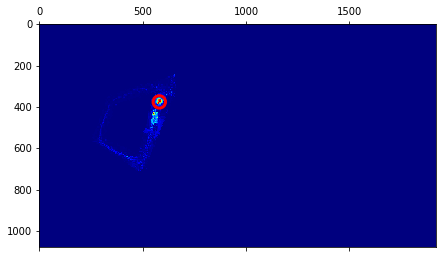

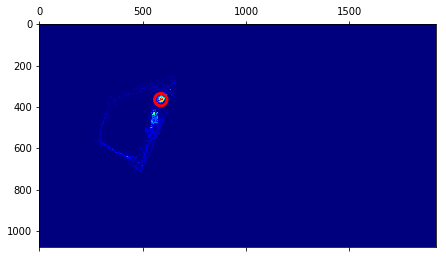

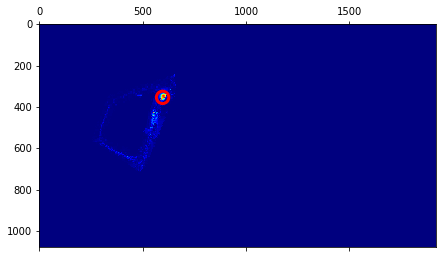

In [94]:
for idx, co in enumerate(pixel_cos): 
    plt.matshow(pix_imgs[idx], cmap='jet')
    ax = plt.gca()
    #ax.set_title("Pixel Nr:", str(idx))
    ax.add_artist(plt.Circle(co[::-1], 30, color='r', fill=False, linewidth=3))

KeyboardInterrupt: 

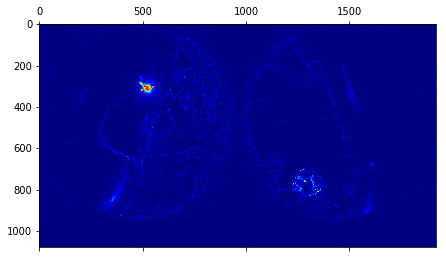

In [26]:
kernel = np.ones([100, 100])

im_idx = 2
max_pix = 0
max_co = [0,0]
for i in range(im0.shape[0] - kernel.shape[0]):
    for j in range(im0.shape[1] - kernel.shape[1]):    
        val = np.sum(data[im_idx, i:i+kernel.shape[0], j:j+kernel.shape[1]]*kernel)
        if val > max_pix:
            max_pix = val
            max_co = [int(i+kernel.shape[0]/2), int(j+kernel.shape[1]/2)]
print(max_pix, max_co)

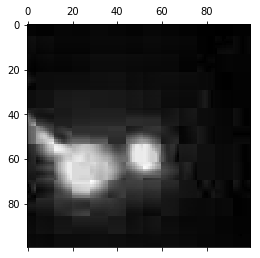

In [51]:
plt.matshow(data[2, 250:350, 500:600], cmap='gray')


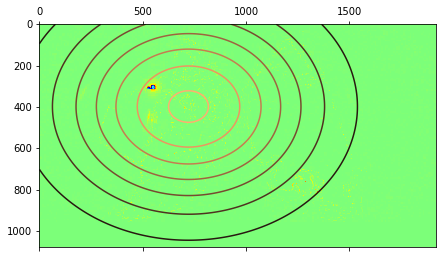

In [39]:
plt.matshow(data[0], cmap='jet')

params = fitgaussian(data[0])
fit = gaussian(*params)

plt.contour(fit(*np.indices(data.shape[1:])), cmap=plt.cm.copper)
ax = plt.gca()
(height, x, y, width_x, width_y) = params


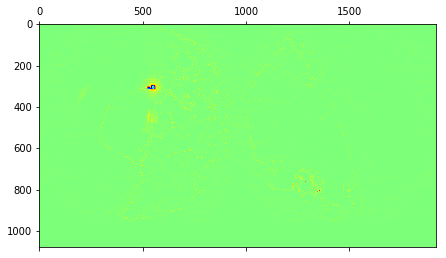

In [32]:
ref_img.shape
plt.matshow(data[0], cmap='jet')

In [35]:
import numpy as np
from numpy import pi, r_
import matplotlib.pyplot as plt
from scipy import optimize

def gaussian(height, center_x, center_y, width_x, width_y):
    """Returns a gaussian function with the given parameters"""
    width_x = float(width_x)
    width_y = float(width_y)
    return lambda x,y: height*np.exp(
                -(((center_x-x)/width_x)**2+((center_y-y)/width_y)**2)/2)

def moments(data):
    """Returns (height, x, y, width_x, width_y)
    the gaussian parameters of a 2D distribution by calculating its
    moments """
    total = data.sum()
    X, Y = np.indices(data.shape)
    x = (X*data).sum()/total
    y = (Y*data).sum()/total
    col = data[:, int(y)]
    width_x = np.sqrt(np.abs((np.arange(col.size)-y)**2*col).sum()/col.sum())
    row = data[int(x), :]
    width_y = np.sqrt(np.abs((np.arange(row.size)-x)**2*row).sum()/row.sum())
    height = data.max()
    return height, x, y, width_x, width_y

def fitgaussian(data):
    """Returns (height, x, y, width_x, width_y)
    the gaussian parameters of a 2D distribution found by a fit"""
    params = moments(data)
    errorfunction = lambda p: np.ravel(gaussian(*p)(*np.indices(data.shape)) -
                                 data)
    p, success = optimize.leastsq(errorfunction, params)
    return p

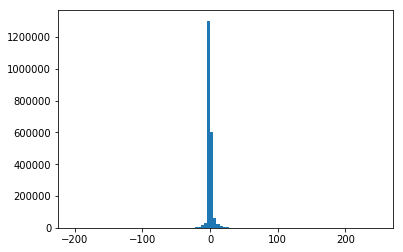

In [61]:
plt.hist((im[:,:,1] - im0).reshape(-1), bins=100);

In [106]:
pix_imgs = data[::3]
len(pix_imgs)

60